# Model training from datafiles. 

## Imports 

In [1]:
import copy
import random 
import cv2
import math

import tensorflow           as tf
import matplotlib.pyplot    as plt
import numpy                as np
import datetime             as dt

from IPython.display  import clear_output
from keras 			  import regularizers

from scipy.stats      import norm
from keras.utils      import np_utils

import os
import pickle

from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten
from keras.layers import Conv1D,MaxPooling1D,Conv2D,MaxPooling2D
from keras.utils  import plot_model
from keras.optimizers import Adam

import keras.backend as k

## Colab Mounting

In [2]:
from google.colab     import drive

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AI_Research/Hilbert_AppliedIntelligence/')

Mounted at /content/drive


## Timestamp and Storage

In [3]:
startdate = dt.datetime.now()
timestamp = startdate.strftime('%d%m_%H%M%S')

os.mkdir('Results_'+timestamp)
os.chdir('Results_'+timestamp)

## Figure Formatting options

In [4]:
figure_size = (17.5,8)

# font sizes
fs = 20 #fontsize
ts = 25 #titlesize
ls = 15 #legendsize
tick_size = 15

# visual settings
ms = 10
lw = 2

# Markers and linetypes
my_markers = ['o','v','>','<','^','s','+','x','p','h']
line_styles = ["solid","dashed","dotted","dashdot"]

## Loading input data and labels

In [5]:
with (open('../Datasets/Imagenette_Transformed_Hilbert_pt1.dat',"rb")) as data_source:
    loaded_data = pickle.load(data_source)
    data_source.close()

print(loaded_data.keys())

dict_keys(['Training', 'Validation'])


In [6]:
# loaded_data = my_data
my_data = {}
my_data["Hilbert"]= {}
my_data["Hilbert"]["Data"] = loaded_data["Training"]["Data"]["Hilbert"]
my_data["Hilbert"]["Label"] = loaded_data["Training"]["Label"]
del(loaded_data)

In [7]:
input_shape = my_data["Hilbert"]["Data"].shape
print(input_shape) 
# print(my_data["Dotprint"].keys())

(6447, 16384, 3)


In [8]:
class_labels =['tench','English springer','cassette player','chain saw','church','French horn','garbage truck','gas pump','golf ball','parachute']
nb_classes = len(class_labels)

## Model definition

In [9]:
# Define hyperparameters and architecture
filtersize_1d_small = 16
filtersize_1d_medium= 32
filtersize_1d_large = 64

kernelsize_1d_small = 4
kernelsize_1d_lowmed= 9
kernelsize_1d_medium= 16
kernelsize_1d_large = 25

filtersize_2d_small = 16
filtersize_2d_medium= 32
filtersize_2d_large = 64

kernelsize_2d_small = (2,2)
kernelsize_2d_medium= (4,4)
kernelsize_2d_large = (8,8)

input_shape_1d = input_shape[1:]
# input_shape_2d = myOriginalset.shape[1:]
# print("Input shapes for 1D and 2D:",input_shape_1d, input_shape_2d)

optimizer  = 'adam'
activation = 'relu'
my_loss    = 'categorical_crossentropy'
my_metric  = 'top-5-accuracy'

mystride   = 2

In [10]:
# 1D model
def model1d_VGG16():
    model1d = Sequential()
    model1d.add(Conv1D(64,9,strides=mystride,activation=activation,input_shape=input_shape_1d))
    model1d.add(Conv1D(128,9,strides=mystride,activation=activation))
    # model1d.add(Dropout(0.25))

    model1d.add(MaxPooling1D(4))
    model1d.add(Conv1D(256,16,strides=mystride,activation=activation))
    model1d.add(Conv1D(256,16,strides=mystride,activation=activation))
    # model1d.add(Dropout(0.25))

    model1d.add(MaxPooling1D(4))
    model1d.add(Conv1D(512,9,strides=mystride,activation=activation))
    model1d.add(Conv1D(512,9,strides=mystride,activation=activation))

    model1d.add(MaxPooling1D(4))
    # model1d.add(Dropout(0.25))
    model1d.add(Conv1D(512,9,strides=mystride,activation=activation))
    model1d.add(Conv1D(512,9,strides=mystride,activation=activation))
    model1d.add(MaxPooling1D(4))

    model1d.add(Flatten())
    
    model1d.add(Dense(2048,activation=activation))
    model1d.add(Dense(2048,activation=activation))
    model1d.add(Dense(nb_classes,activation='softmax'))
    
    return model1d

In [22]:
def model1d_regularized():    
    model1d = Sequential()
    model1d.add(Conv1D(64,
                       9,
                       strides=mystride,
                       activation=activation,
                       input_shape=input_shape_1d,
                       kernel_regularizer=regularizers.l2(0.1),
                       bias_regularizer=regularizers.l2(0.1)))
    model1d.add(MaxPooling1D(4))
    model1d.add(Dropout(0.25))
    model1d.add(Conv1D(128,
                       9,
                       strides=mystride,
                       activation=activation,
                       kernel_regularizer=regularizers.l2(0.1),
                       bias_regularizer=regularizers.l2(0.1)))
    model1d.add(MaxPooling1D(4))
    model1d.add(Dropout(0.25))
    model1d.add(Conv1D(256,
                       9,
                       strides=mystride,
                       activation=activation,
                       kernel_regularizer=regularizers.l2(0.01),
                       bias_regularizer=regularizers.l2(0.01)))
    model1d.add(Flatten())
    
    model1d.add(Dense(64,activation=activation,
                      kernel_regularizer=regularizers.l2(0.1),
                      bias_regularizer=regularizers.l2(0.1)))
    model1d.add(Dense(nb_classes,activation='softmax'))

    
    return model1d
    

## Hyperparameters

In [34]:
# These features are to be evaluated as an average per epoch
nb_epoch = 1_000  #40 too fast convergence to check the details. 
nb_batch = [25] #,50] # [64,128,200]
nb_runs = 1

# Hyperparameters
my_lr = 0.001
# optimizer = tf.keras.optimizers.Adam(learning_rate=my_lr)
optimizer = Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
top_5_Categorical = tf.keras.metrics.TopKCategoricalAccuracy(k=5, name="top_k_categorical_accuracy", dtype=None)
# kernelsizes = [kernelsize_1d_small,kernelsize_1d_lowmed,kernelsize_1d_medium,kernelsize_1d_large]

## Model training

In [ ]:
my_features = {}
total_runs = len(nb_batch)*nb_runs
run_counter = 0
my_transform = "Hilbert"

x_train = my_data[my_transform]["Data"]
y_train = my_data[my_transform]["Label"]

# x_train = my_data[my_transform]["Data"][:-500]
# y_train = my_data[my_transform]["Label"][:-500]

# x_val = my_data[my_transform]["Data"][-500:]
# y_val = my_data[my_transform]["Label"][-500:]

for my_batch in nb_batch:
    modelstart = dt.datetime.now()
    my_features[my_batch] = {}
    for i in range(nb_runs):
        run_start = dt.datetime.now()
        my_features[my_batch][i] = {}
        # mymodel = model1d_VGG16()
        mymodel = model1d_regularized()

        clear_output(wait=True)
        print("Running models: %.2f" %(run_counter/total_runs),"%")

        #mymodel.compile(optimizer='adam',loss=my_loss,metrics=['accuracy','top_3_categorical_accuracy'])
        #history = mymodel.fit(x_train,y_train,batch_size=my_batch,epochs=nb_epoch,verbose=1,validation_data=(x_val,y_val))
        mymodel.compile(optimizer=optimizer,loss=my_loss,metrics=['accuracy',top_5_Categorical])
        history = mymodel.fit(x_train,y_train,batch_size=my_batch,epochs=nb_epoch,verbose=1,validation_split=0.1)
        my_features[my_batch][i]["train_accuracy"] = history.history['accuracy']
        my_features[my_batch][i]["train_loss"] = history.history['loss']
        my_features[my_batch][i]["val_accuracy"] = history.history['val_accuracy']
        my_features[my_batch][i]["val_loss"] = history.history['val_loss']
        
        k.clear_session()
        with (open("Features_Run%i_Batch%i.dat" %(i,my_batch),"wb")) as my_file:
            pickle.dump(my_features,my_file,protocol=pickle.HIGHEST_PROTOCOL)
            my_file.close()
        del(my_features)
        del(mymodel)
        del(history)

Running models: 0.00 %
Epoch 1/1000
233/233 [==============================] - 6s 22ms/step - loss: 3.4969 - accuracy: 0.1115 - top_k_categorical_accuracy: 0.5147 - val_loss: 2.3047 - val_accuracy: 0.0930 - val_top_k_categorical_accuracy: 0.4868
Epoch 2/1000
233/233 [==============================] - 5s 20ms/step - loss: 2.3032 - accuracy: 0.1050 - top_k_categorical_accuracy: 0.5100 - val_loss: 2.3035 - val_accuracy: 0.1008 - val_top_k_categorical_accuracy: 0.4930
Epoch 3/1000
233/233 [==============================] - 5s 21ms/step - loss: 2.3027 - accuracy: 0.1039 - top_k_categorical_accuracy: 0.5109 - val_loss: 2.3030 - val_accuracy: 0.1008 - val_top_k_categorical_accuracy: 0.4930
Epoch 4/1000
233/233 [==============================] - 5s 20ms/step - loss: 2.3024 - accuracy: 0.1072 - top_k_categorical_accuracy: 0.5098 - val_loss: 2.3035 - val_accuracy: 0.1008 - val_top_k_categorical_accuracy: 0.4930
Epoch 5/1000
233/233 [==============================] - 5s 20ms/step - loss: 2.3027 -

In [31]:
if 0:
    with (open("test_dump.phd","wb")) as my_file:
        pickle.dump(my_features,my_file,protocol=pickle.HIGHEST_PROTOCOL)
        my_file.close()
    del(my_features)

In [32]:
if 1:
    with (open("Features_Run0_Batch50.dat","rb")) as my_file:
        my_features = pickle.load(my_file)
        my_file.close()
    print(my_features.keys())

dict_keys([50])


KeyError: ignored

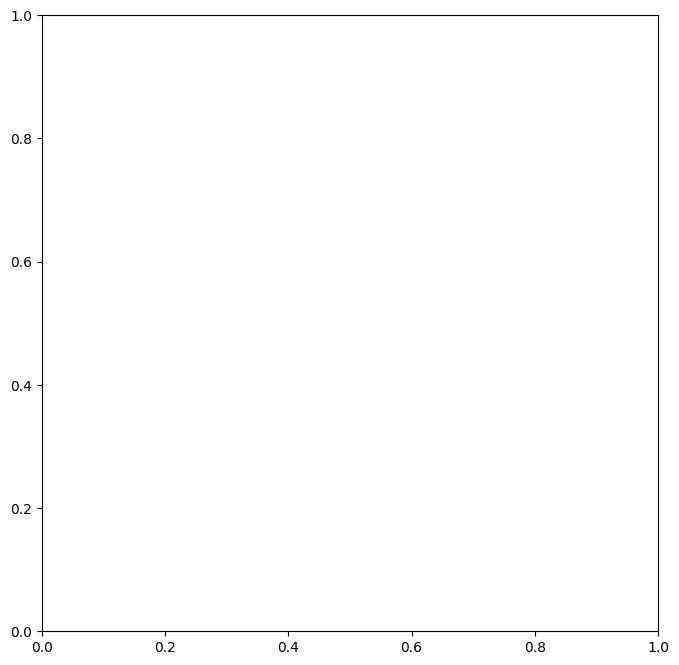

In [33]:
plt.figure(figsize=(17.5,8))

plot_nb = 1
for my_batch in nb_batch[:1]:
    plt.subplot(len(nb_batch),2,plot_nb)
    plot_nb+=1
    for my_run in range(nb_runs):
        plt.plot(range(nb_epoch),my_features[my_batch][my_run]["train_accuracy"],label="run:"+str(my_run),marker='o')
    
    plt.title("Accuracy")
    plt.xlabel('Batch Size')
    plt.ylabel('Accuracy (%)')
plt.legend(loc="upper left", bbox_to_anchor=(1,1))

savefiles = 0
if savefiles:
  savedate = dt.datetime.now().strftime("%Y%m%d_%H%M")
  save_filename = "Accuracies_"+savedate+".png"
  print("Saving plot to",save_filename)
  plt.savefig(save_filename, bbox_inches='tight')

savefiles = 0

plt.show()

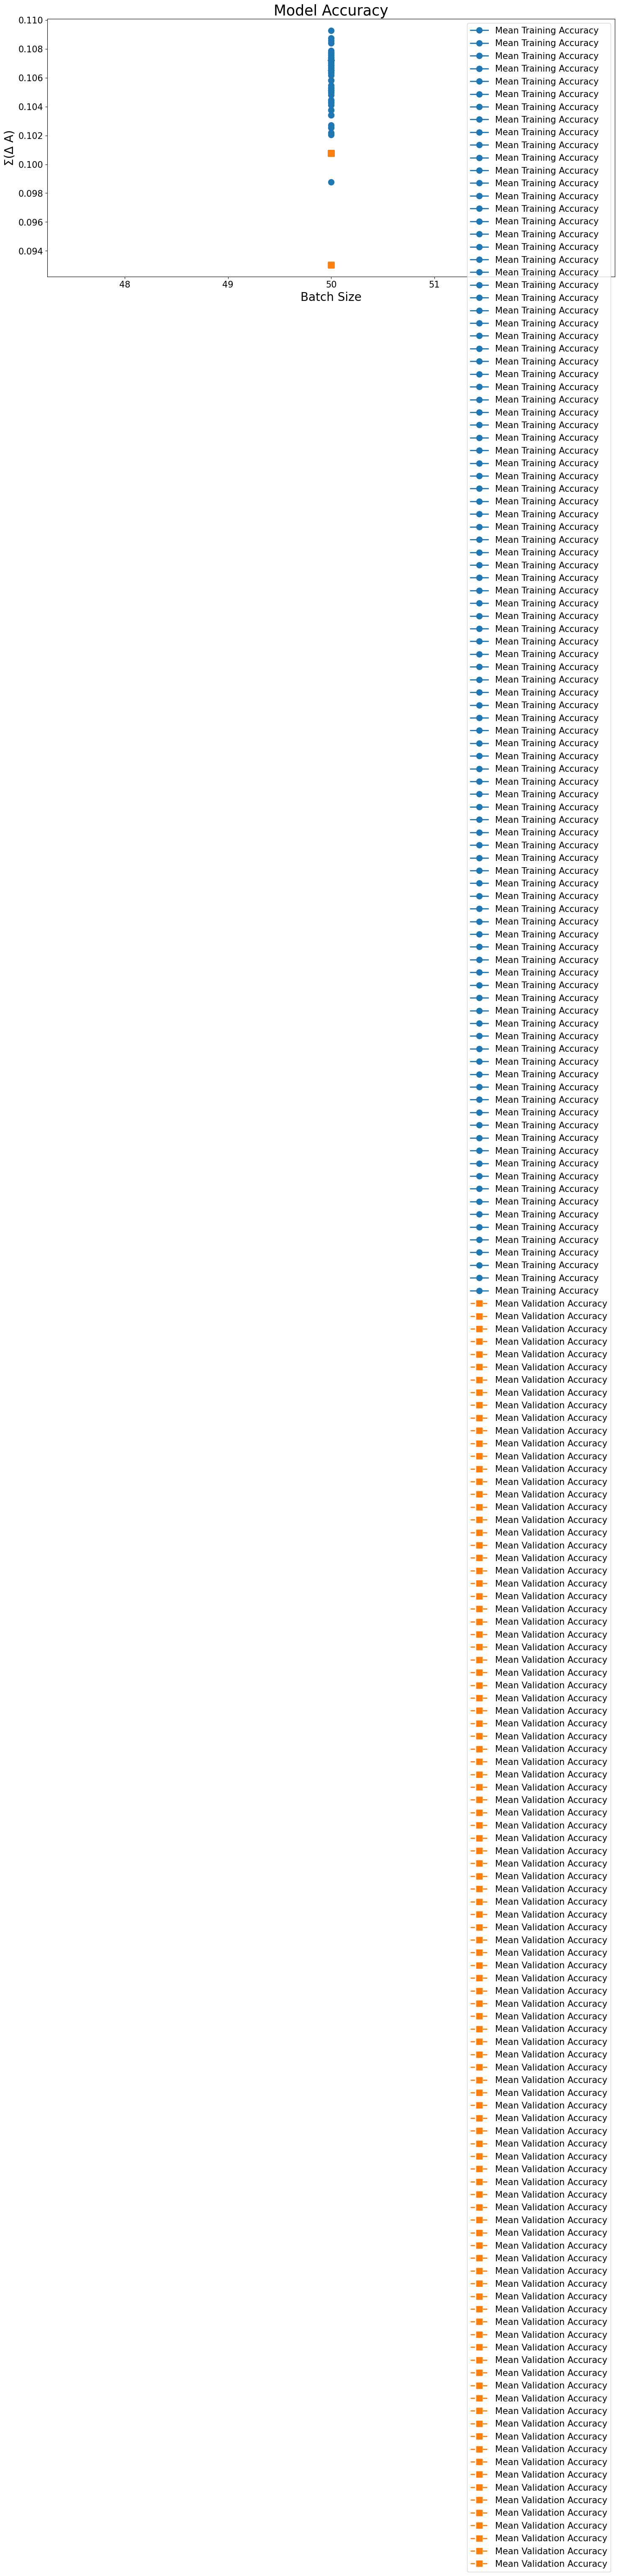

In [28]:
fig = plt.figure(figsize=figure_size)

savefiles = 1

linestyles = ["solid","-","-."]
stylecounter = 0
nb_plots =5

plot_row = 2
plot_it = 0
mykeychain = ['Hilbert']

my_acc_means = list()
my_val_acc_means = list()
my_quantiles = list()
my_val_quantiles = list()
batch_iterator = 0

for my_batch in nb_batch:
    linestyle = linestyles[stylecounter]

    acc_means = np.empty((nb_epoch))
    acc_stds = np.empty((nb_epoch))
    loss_means = np.empty((nb_epoch))
    loss_stds = np.empty((nb_epoch))
    val_acc_means = np.empty((nb_epoch))
    val_acc_stds = np.empty((nb_epoch))
    left_quantile_25 = np.empty((nb_epoch))
    right_quantile_75 = np.empty((nb_epoch))
    quantiles = np.empty((nb_epoch,2))
    
    for epoch in range(nb_epoch):
        acc_means[epoch],acc_stds[epoch] = norm.fit([my_features[my_batch][run]["train_accuracy"][epoch] for run in range(nb_runs)])
        loss_means[epoch],loss_stds[epoch] = norm.fit([my_features[my_batch][run]["train_loss"][epoch] for run in range(nb_runs)])
        val_acc_means[epoch],val_acc_stds[epoch] = norm.fit([my_features[my_batch][run]["val_accuracy"][epoch] for run in range(nb_runs)])
        myleftquantile = abs(acc_means[epoch]-np.quantile([my_features[my_batch][run]["train_accuracy"][epoch] for run in range(nb_runs)],0.25))
        myrightquantile = abs(np.quantile([my_features[my_batch][run]["train_accuracy"][epoch] for run in range(nb_runs)],0.75)-acc_means[epoch])
        val_myleftquantile = abs(val_acc_means[epoch]-np.quantile([my_features[my_batch][run]["val_accuracy"][epoch] for run in range(nb_runs)],0.25))
        val_myrightquantile = abs(np.quantile([my_features[my_batch][run]["val_accuracy"][epoch] for run in range(nb_runs)],0.75)-val_acc_means[epoch])
        left_quantile_25[epoch] = myleftquantile
        right_quantile_75[epoch] = myrightquantile
        quantiles[epoch] = (myleftquantile,myrightquantile)
        val_quantiles = (val_myleftquantile,val_myrightquantile)
        
    my_acc_means.append(acc_means)
    my_val_acc_means.append(val_acc_means)
    my_quantiles.append(quantiles)
    my_val_quantiles.append(val_quantiles)
    batch_iterator += 1

#     plt.errorbar(nb_batch,my_acc_means,yerr=np.vstack(np.transpose(my_quantiles)),
plt.plot(nb_batch, my_acc_means,
            marker=my_markers[0],
            markersize=ms,
            linewidth=lw,
            color="C0", 
            linestyle="-",
            label="Mean Training Accuracy")

#     plt.errorbar(nb_batch,my_val_acc_means,yerr=np.vstack(np.transpose(my_val_quantiles)),
plt.plot(nb_batch,my_val_acc_means,
            marker=my_markers[5],
            markersize=ms,
            linewidth=lw,
            color="C1", 
            linestyle="--",
            label="Mean Validation Accuracy")

plt.legend(fontsize=ls)
plt.xlabel("Batch Size",fontsize=fs)
plt.ylabel("\u03A3(\u0394 A)", fontsize=fs) #/ \u03A3 Q
plt.title("Model Accuracy",fontsize=ts)
plt.tick_params(axis='both',labelsize=tick_size)

if 0 :
  savedate = dt.datetime.now().strftime("%Y%m%d_%H%M")
  save_filename = identifier+"_trainAndValResults_NoSeed_"+savedate+".png"
  print("Saving plot to",save_filename)
  plt.savefig(save_filename, bbox_inches='tight')

plt.show()

In [ ]:
if 0:
    fig = plt.figure(figsize=(20,20))

    savefiles = 0

    linestyles = ["solid","-","-."]
    stylecounter = 0
    nb_plots =3
    plot_row = len(kernelsizes)
    plot_it = 0

    stylecounter = 0
    for my_batch in nb_batch[0]:
        linestyle = linestyles[stylecounter]
        if stylecounter < len(linestyle)-1:
            stylecounter += 1
        else:
            stylecounter = 0
        acc_means = np.empty((nb_epoch))
        acc_stds = np.empty((nb_epoch))
        loss_means = np.empty((nb_epoch))
        loss_stds = np.empty((nb_epoch))
        val_acc_means = np.empty((nb_epoch))
        val_acc_stds = np.empty((nb_epoch))
        for epoch in range(nb_epoch):
            acc_means[epoch],acc_stds[epoch] = norm.fit([myaccuracy[my_kernel][my_batch][key][run][epoch] for run in range(nb_runs)])
            loss_means[epoch],loss_stds[epoch] = norm.fit([myloss[my_kernel][my_batch][key][run][epoch] for run in range(nb_runs)])
            val_acc_means[epoch],val_acc_stds[epoch] = norm.fit([val_myaccuracy[my_kernel][my_batch][key][run][epoch] for run in range(nb_runs)])
            
        plt.subplot(plot_row,nb_plots,1+plot_it)
        im1 = plt.errorbar(range(1,nb_epoch+1),acc_means*100,acc_stds*100,fmt='o',ls=linestyle,label=key+"_"+str(my_batch))
        plt.title("Test Accuracy: lr: "+str(my_lr)+" Kernel:"+str(my_kernel));plt.xlabel("Epoch");plt.ylabel("%");plt.legend()

        plt.subplot(plot_row,nb_plots,2+plot_it)
        im2 = plt.errorbar(range(1,nb_epoch+1),loss_means,loss_stds,fmt='o',ls=linestyle,label=key+"_"+str(my_batch))
        plt.title("Loss: lr: "+str(my_lr)+" Kernel:"+str(my_kernel));
        plt.xlabel("Epoch");plt.ylabel("");plt.legend()

        plt.subplot(plot_row,nb_plots,3+plot_it)
        im2 = plt.errorbar(range(1,nb_epoch+1),val_acc_means,val_acc_stds,fmt='o',ls=linestyle,label=key+"_"+str(my_batch))
        plt.title("Validation Accuracy: lr: "+str(my_lr)+" Kernel:"+str(my_kernel));
        plt.xlabel("Epoch");plt.ylabel("");plt.legend()

        plot_it+=3

    savefiles = 1
    if savefiles:
        savedate = dt.datetime.now().strftime("%Y%m%d_%H%M")
        save_filename = identifier+"_10ksample_Seededmodel_lr_"+str(my_lr)+"_batch_"+str(nb_batch)+"_Filter_"+str(filtersize_1d_medium)+"Poolinglayer"+savedate+".png"
        print("Saving plot to",save_filename)
        plt.savefig(save_filename, bbox_inches='tight')